# Sección Dígitos


## Preprocesamiento

Nota: Este Notebook lo hice después de haber hecho el correspondiente a los operadores, por lo que muchas de las ideas de aquel notebook fueron reutilizadas en este.

Al igual que hicimos con la sección de operadores, paremos un momento a analizar como nos encontramos:

1. Por recomendación del equipo docente tenemos la idea de cargar el dataset de MNIST de la siguiente manera
```
from keras.datasets import mnist
from functools import lru_cache
@lru_cache(maxsize=1)
def get_mnist_data():
  return mnist.load_data()
```
2.  El dataset nos traerá 70mil imágenes de dígitos, por lo que de igual manera como hicimos con los operadores, los aplanaremos a un vector para construir nuestra matriz de datos. Para esto tomemos en cuenta que ya nos viene separado en: 60mil imágenes para entrenamiento, y 10mil imágenes para prueba.

3.  Investigando un poco, de la página https://www.tensorflow.org/api_docs/python/tf/keras/datasets/mnist/load_data, obtuvimos que el retorno de la función mnist.load_data(), son dos tuplas, una para entrenamiento y otra para prueba. Con esto podemos descomponer nuestro dataset fácilmente.





In [1]:
# Cargamos el dataset
from keras.datasets import mnist
from functools import lru_cache
import numpy as np

@lru_cache(maxsize=1)
def get_mnist_data():
  return mnist.load_data()


(X_entrenamiento, y_entrenamiento), (X_prueba, y_prueba) = get_mnist_data()

print(f"Tamaño de X_entrenamiento: {X_entrenamiento.shape}")
print(f"Tamaño de y_entrenamiento: {y_entrenamiento.shape}")

# Aplanamos la matriz
X_entrenamiento_plano = X_entrenamiento.reshape(-1, 784).astype('float32')
X_prueba_plano = X_prueba.reshape(-1, 784).astype('float32')

print(f"Tamaño de X_entrenamiento_plano: {X_entrenamiento_plano.shape}")
print(f"Tamaño de X_prueba_plano: {X_prueba_plano.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Tamaño de X_entrenamiento: (60000, 28, 28)
Tamaño de y_entrenamiento: (60000,)
Tamaño de X_entrenamiento_plano: (60000, 784)
Tamaño de X_prueba_plano: (10000, 784)


Con esto, ya tenemos la matriz aplanada para representar cada imagen como un vector de $1 \times 784$, solo nos falta, de igual manera como hicimos con los operadores, escalar dicha matriz (normalizarla).

In [2]:
X_entrenamiento_escalado = X_entrenamiento_plano / 255.0
X_prueba_escalado = X_prueba_plano / 255.0

## Entrenamiento

Al ya haber realizado el entrenamiento de los modelos de operadores, lo que haremos en esta sección será bastante parecido. Pasaremos por:

1.  Buscar el parámetro (o los parámetros) de regularización.
2.  Entrenaremos con dicho parámetro.
3.  Haremos un heatmap para visualizar resultados.

Y al final, pasaremos a comparar los 4 modelos y a elegir al ganador.

Por lo que, pasemos con los modelos:


### Regresión Logística

Como mencionamos, pasemos a buscar nuestro parámetro de regularización $C$.

EDIT: La primera vez que traté de buscar el hiperparámetro con los 60mil datos, tomó muchísimo tiempo. Así que se me ocurrió buscar dicho parámetro con una fracción de los datos de entrenamiento, para así aliviar la carga computacional, y una vez hallado el parámetro, si entrenar con la cantidad grande de datos.

In [3]:
# Recordar
semilla_cedula = 30136061

# Lo mencionado arriba en el EDIT
from sklearn.model_selection import train_test_split

X_entrenamiento_red, _, y_entrenamiento_red, _ = train_test_split(
    X_entrenamiento_escalado,
    y_entrenamiento,
    train_size=10000,
    stratify=y_entrenamiento, # Usamos stratify para que haya balance de clases
    random_state=semilla_cedula
)

In [4]:
# Código análogo al usado en la sección de Operadores
from sklearn import model_selection
from sklearn.linear_model import LogisticRegression # Modelo de RL
from sklearn.model_selection import cross_val_score # Lo usaremos para hallar el C
from sklearn.metrics import accuracy_score, classification_report # Métricas para comparar más adelante, con classification report sacaremos las métricas del F1 score, la precisión y la sensibilidad
import time # Nuevo debido al tiempo que tomaba entrenar

# Posibles valores de regularización, recordemos que C pequeño es mucha regularización
posibles_C = [0.01, 0.1, 1, 10, 100, 1000]
promedios = []

inicio_total = time.time()

for c in posibles_C:
    #Inicio de la iteración
    inicio = time.time()
    # Creamos el modelo
    modelo_rl = LogisticRegression(C=c, max_iter=1000, random_state=semilla_cedula)
    # Hacemos la validación cruzada
    scores = cross_val_score(modelo_rl, X_entrenamiento_red, y_entrenamiento_red, cv=5, scoring='accuracy')
    # Calculamos el promedio y lo guardamos
    score_medio = np.mean(scores)
    promedios.append(score_medio)
    # Mostramos un debugging pequeño
    fin = time.time()
    print(f"C: {c}, Score medio: {score_medio}, Tiempo de ejecución: {fin - inicio}")


# Buscamos el mejor
mejor_c = posibles_C[np.argmax(promedios)]
print(f"Mejor C RL: {mejor_c}")

fin_total = time.time()
print(f"Tiempo total de búsqueda: {fin_total - inicio_total}")

# Entrenamos el modelo
inicio = time.time()
modelo_rl_final = LogisticRegression(C=mejor_c, max_iter=1000, random_state=semilla_cedula)
modelo_rl_final.fit(X_entrenamiento_escalado, y_entrenamiento)
fin = time.time()
print(f"Tiempo de entrenamiento final: {fin - inicio}")

# Hacemos el test
y_pred_rl = modelo_rl_final.predict(X_prueba_escalado)

# Resultados
precision_rl = accuracy_score(y_prueba, y_pred_rl)
print(f"Precisión del modelo RL: {precision_rl}")
print(classification_report(y_prueba, y_pred_rl, zero_division=0)) # Usamos zero_division para evitar unos warnings molestos cuando no logra predecir una clase.

# Almacenamos para comparar futuro
clasificacion_rl = classification_report(y_prueba, y_pred_rl, zero_division=0)

C: 0.01, Score medio: 0.8933, Tiempo de ejecución: 43.714340925216675
C: 0.1, Score medio: 0.9052, Tiempo de ejecución: 48.19433069229126
C: 1, Score medio: 0.8968999999999999, Tiempo de ejecución: 67.44264888763428
C: 10, Score medio: 0.8722999999999999, Tiempo de ejecución: 109.46984839439392
C: 100, Score medio: 0.8648000000000001, Tiempo de ejecución: 86.67972421646118
C: 1000, Score medio: 0.8632, Tiempo de ejecución: 80.11595368385315
Mejor C RL: 0.1
Tiempo total de búsqueda: 435.6208109855652
Tiempo de entrenamiento final: 47.69055199623108
Precisión del modelo RL: 0.9259
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       980
           1       0.96      0.98      0.97      1135
           2       0.94      0.90      0.92      1032
           3       0.91      0.91      0.91      1010
           4       0.93      0.93      0.93       982
           5       0.90      0.87      0.89       892
           6       0.94      0.95  

De este modelo obtuvimos resultados bastante interesantes:
1.  El $C$ ganador fue de $0.1$.
2.  La precisión del modelo fue bastante aceptable, de $≈0.93$.
3.  Como valores problemáticos tenemos el 8 y el 5, quienes tienen las menores métricas, lo cual tiene sentido puesto que un 5 mal trazado podría parecerse a un 6, y un 8 mal trazado podría parecerse a un 5 o incluso a un 3 también.
4.  El mejor valor sin discusión fue el 1, con un trazo bastante único, y le sigue de cerca el 0.
5.  Con este dataset que no tiene un balance de clases perfectos, si notamos que hay diferencias en las dos últimas métricas. Donde macro avg es ligeramente inferior al promedio ponderado (weighted avg).

Pasemos a ver el heatmap acorde a su matriz de confusión.

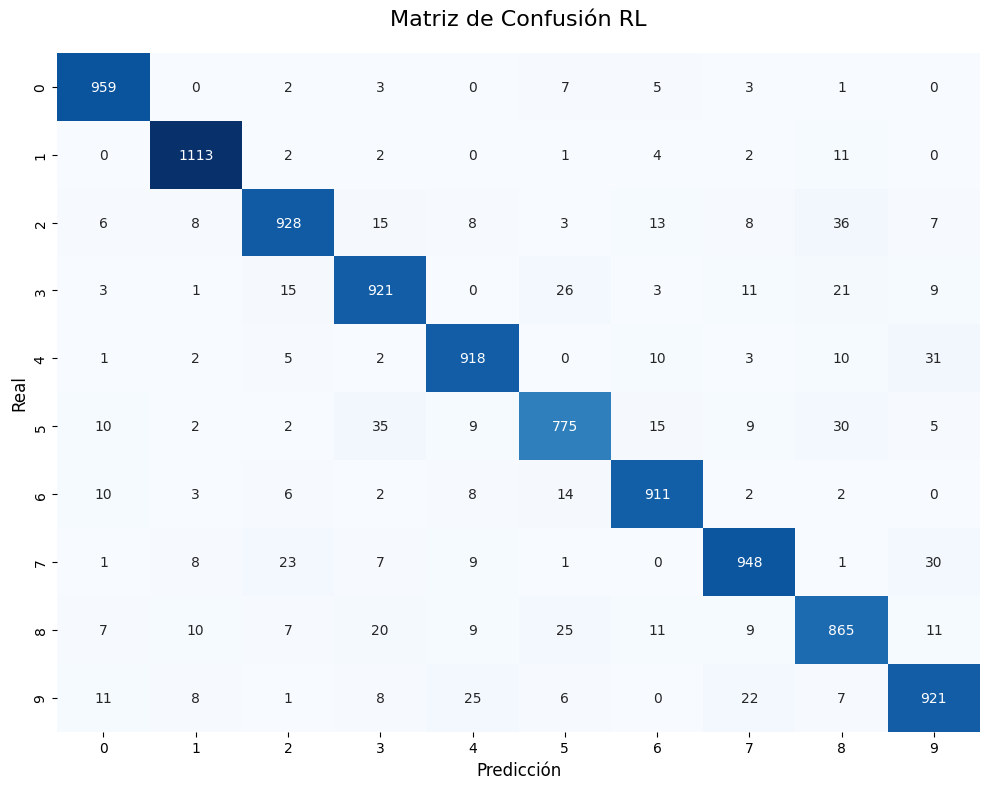

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


matriz_confusion_rl = confusion_matrix(y_prueba, y_pred_rl)
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_confusion_rl, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=[str(i) for i in range(10)],
            yticklabels=[str(i) for i in range(10)])

plt.title('Matriz de Confusión RL', fontsize=16, pad=20)
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Real', fontsize=12)

plt.tight_layout()
plt.show()

Observando el heatmap, confirmamos la confusión que planteamos en el punto anterior pero con ciertos matices:

1.  La mayoría de 8 están siendo confundidos con 5 y con 3.
2.  La mayoría de 5 están siendo confundidos con 3 y también con 8.

Esto nos dice que claramente tenemos un problema con estos 3 números, y no es casualidad, ciertamente se parecen bastante.

Dichas confusiones podrían explicarse de la siguiente manera, al pasar la imagen a una de $28\times28$ claramente se pierde calidad de la misma, y al ser aplanada y convertida en un vector numérico, los trazos del 8 se asimilan al vector generado por los trazos del 5 y 3. Lo mismo pasa con los otros números confusos.

Otra cosa a destacar, es que si vemos la fila del 2, muchísimos casos están pasando como 8, esto se puede explicar porque ciertas personas suelen dibujarlo como un "ricito" al 2 cuando lo escriben, lo que hace que el modelo lo confunda con los rizos del 8.

### K-NN

Ahora pasando al algoritmo K-NN, de antemano podemos pensar que este algoritmo nos va a dar ciertos problemas, ya que es uno perezoso, este no aprende en realidad, sino que cada vez que probemos un dato, se calculará la distancia de este a cada uno de los puntos del modelo, lo cual dará tiempos de ejecución muy grandes si $k$ es muy grande. Aún así, pasemos a buscar su parámetro de regularización como hicimos previamente:

In [14]:
from sklearn.neighbors import KNeighborsClassifier

valores_k = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21]
valores_p = [1, 2]
promedios_knn = []

# Lo que buscamos
mejor_k = None
mejor_p = None
mejor_score = 0

inicio_total = time.time()

for p in valores_p:
  for k in valores_k:
      inicio = time.time()
      modelo_knn = KNeighborsClassifier(n_neighbors=k, p=p)
      scores = cross_val_score(modelo_knn, X_entrenamiento_red, y_entrenamiento_red, cv=5, scoring='accuracy')
      score_medio = np.mean(scores)
      fin = time.time()
      print(f"  k={k} | p={p} -> Promedio Score: {score_medio} -> Tiempo de ejecución: {fin-inicio}")

      if score_medio > mejor_score:
            mejor_score = score_medio
            mejor_k = k
            mejor_p = p


print(f"Mejor K: {mejor_k}")
if mejor_p == 1:
  print("Mejor distancia: Manhattan")
else:
  print("Mejor distancia: Euclideana")

fin_total = time.time()
print(f"Tiempo total de búsqueda: {(fin_total - inicio_total)/60} minutos")

# Entrenamos el modelo
inicio = time.time()
knn_final =  KNeighborsClassifier(n_neighbors=mejor_k, p=mejor_p)
knn_final.fit(X_entrenamiento_escalado, y_entrenamiento)
final = time.time()
print(f"Tiempo de entrenamiento final: {final - inicio}")
# Hacemos el test
y_pred_knn = knn_final.predict(X_prueba_escalado)

# Resultados
precision_knn = accuracy_score(y_prueba, y_pred_knn)
print(f"Precisión del modelo KNN: {precision_knn}")
print(classification_report(y_prueba, y_pred_knn, zero_division=0)) # Usamos zero_division para evitar unos warnings molestos cuando no logra predecir una clase.

# Almacenamos para comparar futuro
clasificacion_knn = classification_report(y_prueba, y_pred_knn, zero_division=0)

  k=1 | p=1 -> Promedio Score: 0.9362999999999999 -> Tiempo de ejecución: 97.71672582626343
  k=3 | p=1 -> Promedio Score: 0.9356000000000002 -> Tiempo de ejecución: 96.46462655067444
  k=5 | p=1 -> Promedio Score: 0.9322000000000001 -> Tiempo de ejecución: 97.86323070526123
  k=7 | p=1 -> Promedio Score: 0.9318 -> Tiempo de ejecución: 95.84003567695618
  k=9 | p=1 -> Promedio Score: 0.9276000000000002 -> Tiempo de ejecución: 96.0855872631073
  k=11 | p=1 -> Promedio Score: 0.9234 -> Tiempo de ejecución: 95.768723487854
  k=13 | p=1 -> Promedio Score: 0.9209999999999999 -> Tiempo de ejecución: 96.32225227355957
  k=15 | p=1 -> Promedio Score: 0.9193999999999999 -> Tiempo de ejecución: 96.05636596679688
  k=17 | p=1 -> Promedio Score: 0.9160999999999999 -> Tiempo de ejecución: 95.73176598548889
  k=19 | p=1 -> Promedio Score: 0.9132 -> Tiempo de ejecución: 95.5141613483429
  k=21 | p=1 -> Promedio Score: 0.9113 -> Tiempo de ejecución: 95.10736632347107
  k=1 | p=2 -> Promedio Score: 0.9

Analizando los resultados, nos encontramos con una salida mucho más agradable, desde la precisión total del modelo que fue bastante alta comparada con la anterior ($\approx0.97$). A su vez, también podemos observar que los recall son bastante altos, igual que la precisión de cada clase.

Con este modelo podemos destacar el $k=3$, que comparado con el resultante en la sección de operadores, destaca pues cuando antes solo preguntaba a 1 vecino, ahora pasa a 3, lo que hace que ese ruido se vaya difuminando. Además, gracias a usar números impares, evitamos ese molesto empate.

También destacamos que se usó la norma Euclideana, igual que el usado para la sección de operadores, por lo que podríamos decir que esta norma ajusta mejor para los dataset relacionados con imágenes.

Como curiosidad, podemos ver que los tiempos de la distancia Manhattan son mucho mayores a los de la distancia Euclideana, esto se debe a como está programada la librería de Scikit Learn. Donde la distancia Euclideana se mediante la multiplicación de matrices (que está sumamente optimizada), mientras que la distancia Manhattan si procesa cada dato con los valores absolutos, que son un poco más costosos. (Referencia: "Por qué al usar la distancia Manhattan en Knn tarda más que usar la distancia euclideana". LLM Gemini)

Pasemos a analizar el heatmap para ver esto mejor.



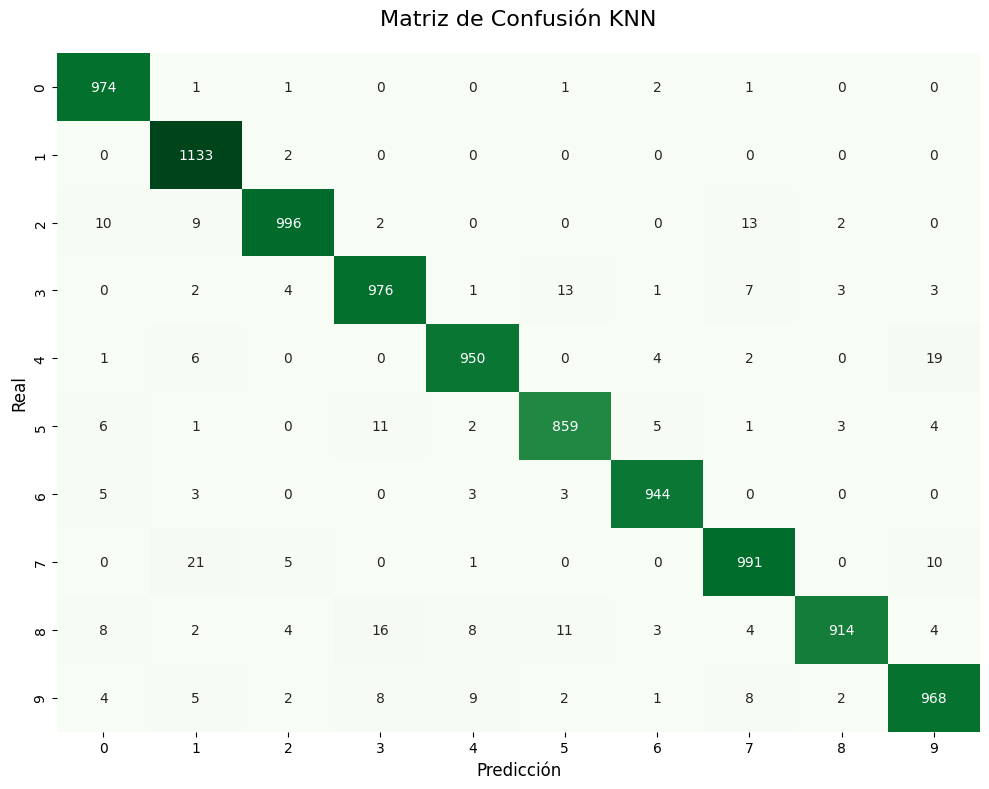

In [7]:
matriz_confusion_knn = confusion_matrix(y_prueba, y_pred_knn)
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_confusion_knn, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=[str(i) for i in range(10)],
            yticklabels=[str(i) for i in range(10)])

plt.title('Matriz de Confusión KNN', fontsize=16, pad=20)
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Real', fontsize=12)

plt.tight_layout()
plt.show()

Como podemos observar, esas clases problemáticas de antes (la del 5 y 8), mejoraron bastante su recall, y en general todos los números mejoraron su sensibilidad, esto significa que el modelo está mitigando esos "robos" de clases. Cabe destacar que trazos simples como los del 1 siguen siendo muy favorables en este modelo también.

### SVM

Para esto modelo, tal y como hicimos en la sección de operadores, pasaremos a buscar el $C$ de regularización, además del kernel mas favorable:

In [8]:
from sklearn.svm import SVC

valores_c_svm = [0.01, 0.1, 1, 10, 100]
valores_kernel = ['linear', 'rbf', 'poly', 'sigmoid']

mejor_score_svm = 0
mejor_c_svm = None
mejor_kernel = None

inicio_total = time.time()

for k in valores_kernel:

    for c in valores_c_svm:
        inicio = time.time()
        modelo_svm = SVC(C=c, kernel=k, random_state=semilla_cedula)

        scores = cross_val_score(modelo_svm, X_entrenamiento_red, y_entrenamiento_red, cv=5, scoring='accuracy')
        score_medio = np.mean(scores)
        fin = time.time()
        print(f"  C={c}, Kernel={k} -> Promedio: {score_medio} -> Tiempo de ejecución: {fin-inicio}")

        # Guardamos el mejor resultado
        if score_medio > mejor_score_svm:
            mejor_score_svm = score_medio
            mejor_c_svm = c
            mejor_kernel = k

print(f"Mejor C: {mejor_c_svm}")
print(f"Mejor kernel: {mejor_kernel}")

fin_total = time.time()
print(f"Tiempo total de búsqueda: {(fin_total - inicio_total)/60} minutos")

# Entrenamos el modelo
inicio = time.time()
svm_final = SVC(C=mejor_c_svm, kernel=mejor_kernel, random_state=semilla_cedula)
svm_final.fit(X_entrenamiento_escalado, y_entrenamiento)
fin = time.time()
print(f"Tiempo de entrenamiento: {(fin-inicio)/60} minutos")

# Hacemos el test
y_pred_svm = svm_final.predict(X_prueba_escalado)

# Resultados
precision_svm = accuracy_score(y_prueba, y_pred_svm)
print(f"Precisión del modelo SVM: {precision_svm}")
print(classification_report(y_prueba, y_pred_svm, zero_division=0)) # Usamos zero_division para evitar unos warnings molestos cuando no logra predecir una clase.

# Almacenamos para comparar futuro
clasificacion_svm = classification_report(y_prueba, y_pred_svm, zero_division=0)

  C=0.01, Kernel=linear -> Promedio: 0.9186 -> Tiempo de ejecución: 81.85841727256775
  C=0.1, Kernel=linear -> Promedio: 0.9249 -> Tiempo de ejecución: 38.323978424072266
  C=1, Kernel=linear -> Promedio: 0.9058999999999999 -> Tiempo de ejecución: 48.072702407836914
  C=10, Kernel=linear -> Promedio: 0.9010999999999999 -> Tiempo de ejecución: 46.692091941833496
  C=100, Kernel=linear -> Promedio: 0.9010999999999999 -> Tiempo de ejecución: 48.620749950408936
  C=0.01, Kernel=rbf -> Promedio: 0.7248 -> Tiempo de ejecución: 333.06166219711304
  C=0.1, Kernel=rbf -> Promedio: 0.9219000000000002 -> Tiempo de ejecución: 135.9959704875946
  C=1, Kernel=rbf -> Promedio: 0.9564999999999999 -> Tiempo de ejecución: 73.2614893913269
  C=10, Kernel=rbf -> Promedio: 0.9641 -> Tiempo de ejecución: 75.26128196716309
  C=100, Kernel=rbf -> Promedio: 0.9638 -> Tiempo de ejecución: 74.16194272041321
  C=0.01, Kernel=poly -> Promedio: 0.6740999999999999 -> Tiempo de ejecución: 214.85241627693176
  C=0.1,

Con respecto a este modelo, tenemos resultados asombrosos, un $≈0.98$ de precisión total, casi perfecto. A pesar de los 36 minutos que tardó entre el entrenamiento y el ajuste de los parámetros, podríamos considerar que valió totalmente la pena. Ahora bien, viendo los resultados para cada una de las clases, son idóneos, al rededor de $.98$ para todas las clases. Y lo más impresionante de todo, es que se nota una mejoría bastante clara en cuanto al recall, y por tanto al f1-score. En los modelos previos, la clase 5 apenas lograba una sensibilidad del $0.87$ (para RL específicamente). Con este modelo SVM, nuestro peor escenario es la clase 9, con una sensibilidad del $0.97$, muy lejos que ese valor tan pobre de Regresión logística.

Si analizamos más detalladamente los debug de cada iteración tenemos:

1.  A diferencia de la sección de operadores, quien sacó mejor promedio fue el kernel rbf, pero ojo, no se queda nada atrás el que resultó ganador en la sección de operadores (polinomial). Esto nos dice que para características como las del dataset de MNIST, estos espacios multidimensionales son lo mejor que podemos usar.
2.  El parámetro de regularización terminó siendo $C=10$. En SVM, como mencionamos en el notebook de operadores, un valor de $C$ alto indica una menor regularización y una penalización estricta por cada error. Esto nos dice que el modelo creó márgenes más ajustados, exigiendo más al kernel usado.

Pasemos a ver su heatmap.

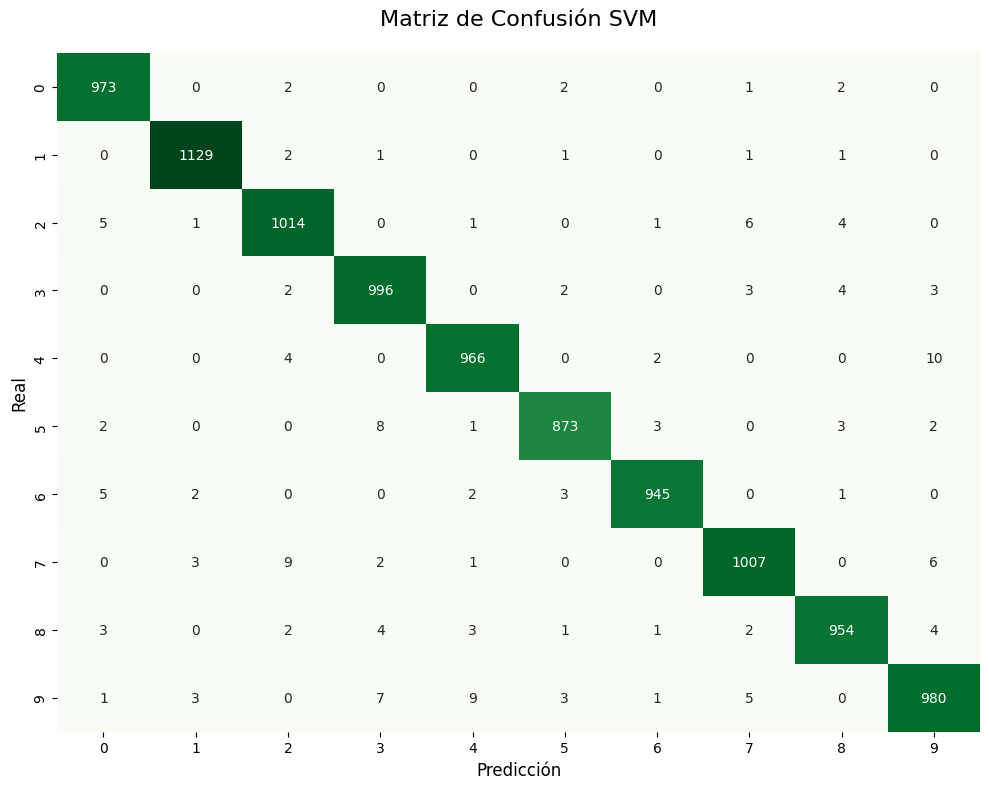

In [9]:
matriz_confusion_svm = confusion_matrix(y_prueba, y_pred_svm)
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_confusion_svm, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=[str(i) for i in range(10)],
            yticklabels=[str(i) for i in range(10)])

plt.title('Matriz de Confusión SVM', fontsize=16, pad=20)
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Real', fontsize=12)

plt.tight_layout()
plt.show()

En comparación con los heatmaps anteriores, el recall de todas las clases aumentó, menos la de la clase 1, que se vió disminuida un poco, aunque sin duda ese es un precio que personalmente pagaría, todo por tener esa mejora en las demás clases. También podemos ver que esos fallos o "robos" de clases se mitigaron muchísimo.

### Árboles de decisión

Para este último modelo, debemos tener en consideración lo que mencionamos en el notebook de operadores. Pues para conseguir todos los parámetros asociados a este modelo, se necesitaron de muchos ciclos anidados, lo que sumado a nuestros 10mil datos que usamos para hallar dichos parámetros, podría resultar en una "masacre" computacional, donde podríamos tardar horas en terminar de ejecutar el algoritmo.

Por lo que, tomando como referencia la experiencia que tuvimos entrenando la sección de operadores, podemos "limpiarnos" la búsqueda de estos hiperparámetros, reduciendo la cantidad de ciclos.

Citando el notebook de operadores: "A pesar de eso, podemos sacar cosas interesantes, pues si denotamos la profundidad máxima fue "Sin límite", es decir, para este caso fue indiferente por lo que pudimos haber ahorrado un ciclo, pasa igual con el decremento de la pureza.

Además vemos que siempre que el decremento de la impureza era la máxima que definimos ($0.05$), obtuvimos los peores resultados. Y que los mejores resultados se alcanzaron con el decremento de la misma del $0.0$, o lo que es igual, lo que se marca como default en la firma del método.

Es decir, estas dos parámetros podemos asignarlos estáticamente al momento de hacer la validación cruzada, y esto lo tomaremos en cuenta al momento de entrenar los modelos de dígitos, pues al ser tantas muestras debemos ser más cuidadosos."

Además para reducir un poco más las iteraciones, usaremos los criterios que presenta IBM en su documentación oficial. Referencia: https://www.ibm.com/es-es/think/topics/decision-trees

Pasando al código:

In [10]:
from sklearn.tree import DecisionTreeClassifier

valores_criterio = ['gini', 'entropy']
valores_min_dividir = [2, 5, 10]
valores_min_hoja = [1, 2, 4]

#Variables estáticas
prof = None
imp = 0.0

mejor_score_tree = 0
mejores_params = {}

inicio_total = time.time()

iteracion = 1

for crit in valores_criterio:
        for dividir in valores_min_dividir:
            for hoja in valores_min_hoja:

                    modelo_tree = DecisionTreeClassifier(
                        criterion=crit, max_depth=prof, min_samples_split=dividir,
                        min_samples_leaf=hoja, min_impurity_decrease=imp, random_state=semilla_cedula
                    )

                    scores = cross_val_score(modelo_tree, X_entrenamiento_red, y_entrenamiento_red, cv=5, scoring='accuracy')
                    score_medio = np.mean(scores)

                    # Debugging para imprimir solo cada 15 iteraciones o al conseguir nuevo mejor
                    if iteracion % 15 == 0 or score_medio > mejor_score_tree:
                        print(f"[{iteracion}] crit={crit}, div={dividir}, hoja={hoja}, -> Score: {score_medio}")

                    if score_medio > mejor_score_tree:
                        mejor_score_tree = score_medio
                        mejores_params = {
                            'criterio': crit,
                            'profundidad': prof,
                            'elementos para dividir': dividir,
                            'elementos por hoja': hoja,
                            'impureza': imp
                        }
                    iteracion += 1

fin_total = time.time()
print(f"Búsqueda completada en {(fin_total - inicio_total)/60:} minutos")

prof_str = str(mejores_params['profundidad']) if mejores_params['profundidad'] is not None else "Sin límite"
print(f"Criterio: {mejores_params['criterio']}")
print(f"Profundidad Max: {prof_str}")
print(f"Min_Elementos_Dividir: {mejores_params['elementos para dividir']}")
print(f"Min_Elementos_Hoja: {mejores_params['elementos por hoja']}")
print(f"Min_Decremento_Impureza: {mejores_params['impureza']}")

inicio_final = time.time()
tree_final = DecisionTreeClassifier(
    criterion=mejores_params['criterio'],
    max_depth=mejores_params['profundidad'],
    min_samples_split=mejores_params['elementos para dividir'],
    min_samples_leaf=mejores_params['elementos por hoja'],
    min_impurity_decrease=mejores_params['impureza'],
    random_state=semilla_cedula
)
tree_final.fit(X_entrenamiento_escalado, y_entrenamiento)
fin_final = time.time()
print(f"Tiempo de entrenamiento: {fin_final - inicio_final} segundos")

y_pred_tree = tree_final.predict(X_prueba_escalado)

# Resultados
precision_tree = accuracy_score(y_prueba, y_pred_tree)
print(f"Precisión del modelo Árbol FINAL: {precision_tree}")
print(classification_report(y_prueba, y_pred_tree, zero_division=0))

clasificacion_tree = classification_report(y_prueba, y_pred_tree, zero_division=0)

[1] crit=gini, div=2, hoja=1, -> Score: 0.7935000000000001
[10] crit=entropy, div=2, hoja=1, -> Score: 0.8009999999999999
[12] crit=entropy, div=2, hoja=4, -> Score: 0.8023999999999999
[15] crit=entropy, div=5, hoja=4, -> Score: 0.8023999999999999
[18] crit=entropy, div=10, hoja=4, -> Score: 0.8032999999999999
Búsqueda completada en 3.8433507720629376 minutos
Criterio: entropy
Profundidad Max: Sin límite
Min_Elementos_Dividir: 10
Min_Elementos_Hoja: 4
Min_Decremento_Impureza: 0.0
Tiempo de entrenamiento: 20.396862506866455 segundos
Precisión del modelo Árbol FINAL: 0.8866
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       980
           1       0.95      0.97      0.96      1135
           2       0.86      0.88      0.87      1032
           3       0.85      0.86      0.85      1010
           4       0.88      0.88      0.88       982
           5       0.84      0.85      0.85       892
           6       0.90      0.89      0.9

Como anticipamos, al reducir los parámetros que buscamos mediante nuestras iteraciones, reducimos considerablemente el tiempo total que pasaríamos en este algoritmo, con un total de $\approx3.5$ minutos. Y podríamos considerar que dicha precisión de $\approx0.88$ ya empezaría a ser un poco mediocre si lo comparamos con la que obtuvimos mediante SVM.

Ahora metiéndonos más de lleno en la métricas para cada clase, vemos que empeora considerablemente el recall de todas las clases, sobretodo de las que marcamos como problemáticas previamente, tanto la del número 8 como la del número 5, a la que tenemos que sumarle la del número 9.

Por lo que, sumando estos resultados considerablemente malos, con los que obtuvimos en la sección de operadores, que también fueron malos para este modelo, podríamos decir que este no es muy útil cuando se trata de trabajar con estas imágenes aplanadas.

De igual forma, grafiquemos su heatmap asociado a la matriz de confusión para detallar mejor la métrica del recall:

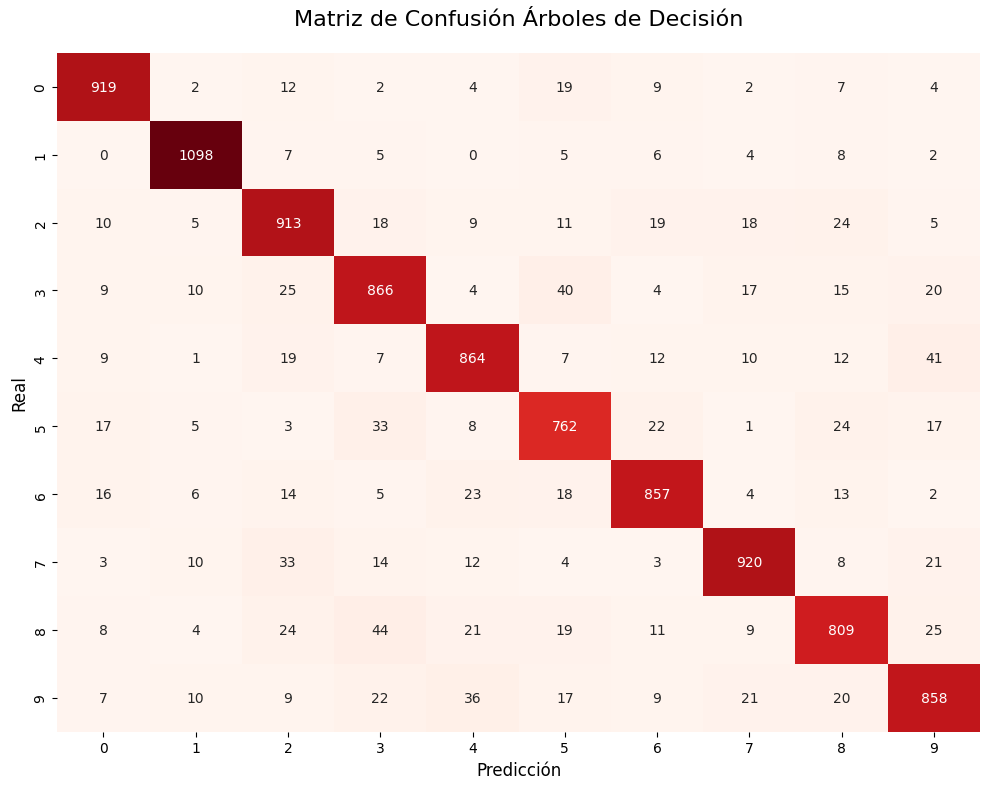

In [11]:
matriz_confusion_tree = confusion_matrix(y_prueba, y_pred_tree)
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_confusion_tree, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=[str(i) for i in range(10)],
            yticklabels=[str(i) for i in range(10)])

plt.title('Matriz de Confusión Árboles de Decisión', fontsize=16, pad=20)
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Real', fontsize=12)

plt.tight_layout()
plt.show()

Como podemos observar, este heatmap nos recuerda bastante al obtenido en el modelo de RL, pero si se quiere, mucho más pesimista. Podemos visualizar fácilmente que se cometen bastantes confusiones de clases, incluyendo nuestra clase "ideal", la del 1, que tiene su peor cantidad de aciertos de todos los modelos.

Para este modelo, las clases problemáticas se magnifican muchísimo, los 3 son mayormente confundidos con 8, los 5 igualmente se confunden con 3.

## Análisis de resultados

Tal cual como hicimos en la sección de operadores, grafiquemos nuestras precisiones para dar los resultados:

Comparativa Precision
             Modelo  Precisión
                SVM     0.9837
                KNN     0.9705
Regresión Logística     0.9259
  Árbol de Decisión     0.8866


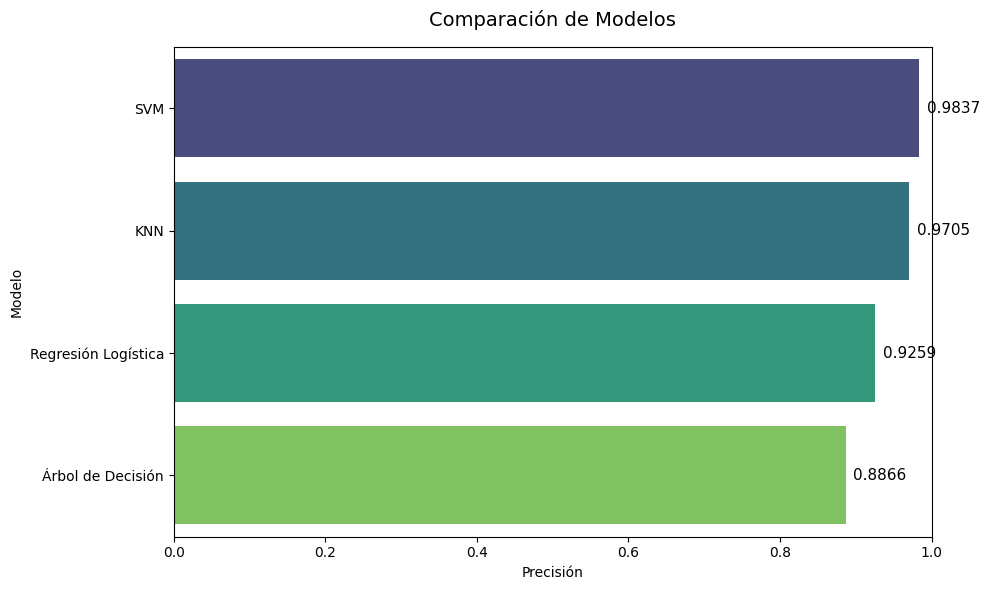

In [12]:
import seaborn as sns
import pandas as pd


resultados = {
    'Modelo': ['SVM', 'KNN', 'Regresión Logística', 'Árbol de Decisión'],
    'Precisión': [precision_svm, precision_knn, precision_rl, precision_tree]
}

df_resultados = pd.DataFrame(resultados).sort_values(by='Precisión', ascending=False)

print("Comparativa Precision")
print(df_resultados.to_string(index=False))


plt.figure(figsize=(10, 6))
sns.barplot(x='Precisión', y='Modelo', hue='Modelo', legend=False, data=df_resultados, palette='viridis')
plt.title('Comparación de Modelos', fontsize=14, pad=15)
plt.xlim(0, 1.0)
for index, value in enumerate(df_resultados['Precisión']):
    plt.text(value + 0.01, index, f'{value:.4f}', va='center', fontsize=11)
plt.tight_layout()
plt.show()

Con esta gráfica, nos queda más que claro que el modelo SVM es el "campeón" de los 4. Destacamos que K-NN no se quedó para nada atrás.

De estos dos, podemos destacar que SVM fue mucho más "duro" de entrenar, pues la búsqueda de sus hiperparámetros nos tomó al rededor de 26 minutos, pero que considerando su excelente resultado, es un precio que pagaríamos a gusto. Además, el hecho de que los kernel nos permitan proyectar nuestro dataset a otros espacios donde se separan más eficientemente, nos da una ventaja muchísimo mayor para adaptarnos a distintos tipos de datos.

Con respecto a los otros dos modelos, RL y Árboles de decisión, en comparación a lo que obtuvimos en la sección de operadores, sus métricas mejoraron considerablemente. Esto se puede deber a dos factores principales:
1.   La cantidad de elementos: Al tener un dataset mucho más amplio, le damos la oportunidad al modelo de verdaderamente aprender. Lo que nos evita problemas de sobreajuste.
2.   Dataset: Que el dataset sea previamente preparado, con todas las imágenes perfectamente en concordancia, ayuda bastante. Si a esto le sumamos el punto anterior, tenemos lo que quizás sea el sueño en esta área de ML.

En general, considerando el punto 1 anterior, todos los modelos mejoraron considerablemente después de haber estado entrenando con 60mil datos.

Ahora bien, para nuestra aplicación nos quedaremos con los modelos de SVM y KNN.



In [13]:
import joblib

joblib.dump(svm_final, 'modelo_svm_campeon_digitos.joblib')
joblib.dump(knn_final, 'modelo_knn_digitos.joblib')

['modelo_knn_digitos.joblib']

Al momento de tratar de subir estos modelos a GitHub, no pude debido a que eran muy pesados, así que los modelos originales los anexaré en la siguiente carpeta en drive, y subiré junto con la app los modelos comprimidos.

[Modelos sin comprimir](https://https://drive.google.com/drive/folders/11Wyg1EvjKdAaQjVOAvVxO4zut3bZ5I2w?usp=drive_link)

In [15]:
joblib.dump(svm_final, 'modelo_svm_campeon_digitos_comprimido.joblib', compress=5)

joblib.dump(modelo_knn, 'modelo_knn_digitos_comprimido.joblib', compress=5)

['modelo_knn_digitos_comprimido.joblib']